# Zone-wise Weighted Set Packing

Independent WSP per zone on FIVE **LandOne** layout ([`data/two_lands.md`](../data/two_lands.md)).

- **25 tiles** — farmer (I) + hire1–4 (II–V), 5 tiles per zone
- **Deduped patterns** — one catalog entry per `(profile, start_day)`; binary assign `x[p,t]` per zone tile
- **Ops caps** — farmer 18, hire1 17, hire2 15, hire3 14, hire4 13 (tape length only; pickups in `animal_with_pickups.json`)
- **Independent cash** — each zone opens day 0 with `3000 × ops / 78`; 1/78 (~$38) unallocated buffer
- **WSP weight cascade** — farmer at base I0; glut products use `base × max(0.01, 1 − count/count_div)` from `GLUT_CAPS`; everything else stays at factor 1.0
- **Open W/F** — buy shortfall at I0 ($25 / $100) inside each zone
- **IRL bank recap** — after solve: `Σ(harvest_units × I0 base)` − setups − buys − hires
- **Per-hand hire** — fib $1 / $1 / $2 / $3 per day, charged inside zone cash



In [1]:
import json
import time

from ortools.sat.python import cp_model



In [2]:
import resource
import tracemalloc
from functools import wraps


def peak_mem(fn):
    @wraps(fn)
    def wrapper(*args, **kwargs):
        rss_before = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        tracemalloc.start()
        try:
            return fn(*args, **kwargs)
        finally:
            _, peak = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            rss_after = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
            print(
                f"{fn.__name__}: tracemalloc peak={peak / 1e6:.1f} MB, "
                f"RSS max={rss_after / 1024:.1f} MB (was {rss_before / 1024:.1f} MB)"
            )

    return wrapper



In [3]:
with open("../data/crop_rollouts.json", "r") as f:
    crops_data = json.load(f)
with open("../data/animal_with_pickups.json", "r") as f:
    animals_data = json.load(f)



In [4]:
NUM_DAYS = 30
NUM_TILES = 25
WHEAT_PRICE = 25
FERT_PRICE = 100
MAX_BUY = NUM_TILES * NUM_DAYS
STARTING_MONEY = 3000

# FIVE layout — data/two_lands.md LandOne (zones I–V, 5 tiles each)
WORKERS = ("farmer", "hire1", "hire2", "hire3", "hire4")
HAND_WORKERS = ("hire1", "hire2", "hire3", "hire4")
HAND_DAILY_COST = {"hire1": 1, "hire2": 1, "hire3": 2, "hire4": 3}

WORKER_TILES = {
    "farmer": list(range(0, 5)),
    "hire1": list(range(5, 10)),
    "hire2": list(range(10, 15)),
    "hire3": list(range(15, 20)),
    "hire4": list(range(20, 25)),
}
NET_TILE_OPS = {
    "farmer": 18,
    "hire1": 17,
    "hire2": 15,
    "hire3": 14,
    "hire4": 13,
}
OPS_DENOM = 78  # 18+17+15+14+13 + 1 buffer
ZONE_MONEY = {w: STARTING_MONEY * NET_TILE_OPS[w] // OPS_DENOM for w in WORKERS}
MONEY_BUFFER = STARTING_MONEY - sum(ZONE_MONEY.values())

TILE_WORKER = (
    ["farmer"] * len(WORKER_TILES["farmer"])
    + ["hire1"] * len(WORKER_TILES["hire1"])
    + ["hire2"] * len(WORKER_TILES["hire2"])
    + ["hire3"] * len(WORKER_TILES["hire3"])
    + ["hire4"] * len(WORKER_TILES["hire4"])
)

CROP_PROFILES = ("no_fert", "with_fert")
ANIMAL_PROFILES = ("no_care", "with_care")
PROFILE_SUFFIXES = ("no_fert", "with_fert", "no_care", "with_care")
GLUT_CAPS = {
    "MELON": {"window": 12, "cap": 52, "count_div": 52},
    "STRAWBERRY": {"window": 18, "cap": 20, "count_div": 20},
    "MILK": {"window": 3, "cap": 25, "count_div": 25},
    "WOOL": {"window": 4, "cap": 19, "count_div": 19},
}
GLUT_PRODUCTS = tuple(GLUT_CAPS)

print("zone banks (ops/78 of $3000):")
for w in WORKERS:
    pct = 100 * NET_TILE_OPS[w] / OPS_DENOM
    print(f"  {w:6s} ops={NET_TILE_OPS[w]:2d}  bank=${ZONE_MONEY[w]:4d}  ({pct:.0f}%)")
print(f"  buffer unused: ${MONEY_BUFFER}")


def worker_for_tile(tile: int) -> str:
    return TILE_WORKER[tile]


def parse_profile_key(profile_key: str):
    for suffix in PROFILE_SUFFIXES:
        token = f"_{suffix}"
        if profile_key.endswith(token):
            return profile_key[: -len(token)], suffix
    raise ValueError(f"unknown profile key: {profile_key}")


def rollout_spec(label: str, profile_name: str):
    if label in crops_data["crops"]:
        spec = crops_data["crops"][label]
        return "crop", spec, spec[profile_name]
    if label in animals_data["animals"]:
        spec = animals_data["animals"][label]
        return "animal", spec, spec[profile_name]
    raise KeyError(label)


def parse_age_maps(profile, label, kind):
    harvest_map = dict(zip(profile["harvest_ages"], profile["yield_per_harvest"]))
    feed_by_age = {}
    fert_use_by_age = {}
    collect_by_age = {}
    wheat_gain_by_age = {}
    for day in profile["days"]:
        age = day["age"]
        acts = day["actions"]
        feed_by_age[age] = 1 if "FEED" in acts else 0
        fert_use_by_age[age] = 1 if "FERTILIZE" in acts else 0
        collect_by_age[age] = 1 if "COLLECT_FERTILIZER" in acts else 0
        if kind == "crop" and label == "WHEAT" and age in harvest_map:
            wheat_gain_by_age[age] = harvest_map[age]
        else:
            wheat_gain_by_age[age] = 0
    return feed_by_age, fert_use_by_age, collect_by_age, wheat_gain_by_age


GLUT_FACTOR_MIN = 0.1


def glut_price_factor(product: str, count: int) -> float:
    spec = GLUT_CAPS.get(product)
    if spec is None:
        return 1.0
    return max(GLUT_FACTOR_MIN, 1.0 - count / spec["count_div"])


def glut_unit_price(base: int, product: str, count: int) -> int:
    return max(1, int(round(base * glut_price_factor(product, count))))


def i0_base_prices():
    prices = {crop: spec["base_price"] for crop, spec in crops_data["crops"].items()}
    for spec in animals_data["animals"].values():
        prices[spec["product"]] = spec["base_price"]
    return prices


BASE_PRICES = i0_base_prices()


def pattern_weight(pat, locked_counts: dict[str, int]) -> int:
    """WSP weight: base at count=0 (farmer); later zones use prior harvest totals."""
    rev = 0
    for product, _hday, yld in pat["harvest_lines"]:
        count = locked_counts.get(product, 0)
        unit = glut_unit_price(BASE_PRICES[product], product, count)
        rev += yld * unit
    return rev - pat["setup_cost"]


def irl_season_accounting(zone_results):
    """IRL bank: sum(harvest_units × I0 base) − setups − market buys − hires."""
    harvest_totals: dict[str, int] = {}
    setup_total = 0
    for res in zone_results:
        for pick in res["selected"]:
            pat = pick["pattern"]
            setup_total += pat["setup_cost"]
            for product, units in pat["harvest_units"].items():
                harvest_totals[product] = harvest_totals.get(product, 0) + units
    harvest_revenue = sum(units * BASE_PRICES[product] for product, units in harvest_totals.items())
    sum_buy_w = sum(r["buy_w_spent"] for r in zone_results)
    sum_buy_f = sum(r["buy_f_spent"] for r in zone_results)
    hire_total = sum(HAND_DAILY_COST[w] * NUM_DAYS for w in HAND_WORKERS)
    delta = (
        harvest_revenue
        - setup_total
        - WHEAT_PRICE * sum_buy_w
        - FERT_PRICE * sum_buy_f
        - hire_total
    )
    return {
        "harvest_totals": harvest_totals,
        "harvest_revenue": harvest_revenue,
        "setup_total": setup_total,
        "buy_w_spent": sum_buy_w,
        "buy_f_spent": sum_buy_f,
        "hire_total": hire_total,
        "delta": delta,
        "ending": STARTING_MONEY + delta,
    }


def empty_daily_harvest():
    return {p: [0] * NUM_DAYS for p in GLUT_PRODUCTS}


def harvest_product(label: str, kind: str) -> str:
    if kind == "animal":
        return animals_data["animals"][label]["product"]
    return label


def add_daily(dst, src):
    for i in range(NUM_DAYS):
        dst[i] += src[i]


def stamp_placement(profile_key: str, start_day: int):
    label, profile_name = parse_profile_key(profile_key)
    kind, spec, profile = rollout_spec(label, profile_name)
    setup_cost = spec["seed_cost"] if kind == "crop" else spec["animal_cost"]
    base_price = spec["base_price"]
    feed_by_age, fert_use_by_age, collect_by_age, wheat_gain_by_age = parse_age_maps(
        profile, label, kind
    )

    daily_tile_ops = [0] * NUM_DAYS
    daily_animal_active = [0] * NUM_DAYS
    daily_feed = [0] * NUM_DAYS
    daily_fert = [0] * NUM_DAYS
    daily_collect = [0] * NUM_DAYS
    daily_wheat = [0] * NUM_DAYS
    occupied = []

    if kind == "crop":
        for day in profile["days"]:
            cal = start_day + day["age"]
            if cal >= NUM_DAYS:
                return None
            occupied.append(cal)
            acts = day["actions"]
            daily_tile_ops[cal] += len(acts)
            age = day["age"]
            daily_feed[cal] += feed_by_age.get(age, 0)
            daily_fert[cal] += fert_use_by_age.get(age, 0)
            daily_collect[cal] += collect_by_age.get(age, 0)
            daily_wheat[cal] += wheat_gain_by_age.get(age, 0)
    else:
        for day in profile["days"]:
            cal = start_day + day["age"]
            if cal >= NUM_DAYS:
                break
            occupied.append(cal)
            acts = day["actions"]
            age = day["age"]
            daily_tile_ops[cal] += len(acts)
            daily_animal_active[cal] = 1
            daily_feed[cal] += feed_by_age.get(age, 0)
            daily_fert[cal] += fert_use_by_age.get(age, 0)
            daily_collect[cal] += collect_by_age.get(age, 0)
            daily_wheat[cal] += wheat_gain_by_age.get(age, 0)
        if not occupied:
            return None

    daily_harvest = empty_daily_harvest()
    for age, yld in zip(profile["harvest_ages"], profile["yield_per_harvest"]):
        d = start_day + age
        if d < NUM_DAYS:
            product = harvest_product(label, kind)
            if product in daily_harvest:
                daily_harvest[product][d] += yld

    harvest_lines = []
    harvest_units = {}
    for age, yld in zip(profile["harvest_ages"], profile["yield_per_harvest"]):
        hday = start_day + age
        if hday >= NUM_DAYS:
            continue
        product = harvest_product(label, kind)
        harvest_lines.append((product, hday, yld))
        harvest_units[product] = harvest_units.get(product, 0) + yld

    cash_by_day = [0] * NUM_DAYS
    cash_by_day[start_day] -= setup_cost
    for _product, hday, yld in harvest_lines:
        cash_by_day[hday] += yld * base_price

    segment = {
        "kind": kind,
        "label": label,
        "profile": profile_name,
        "profile_key": profile_key,
        "start_day": start_day,
        "end_day": max(occupied) + 1,
    }
    return {
        "setup_cost": setup_cost,
        "base_price": base_price,
        "harvest_lines": harvest_lines,
        "harvest_units": harvest_units,
        "cash_by_day": cash_by_day,
        "segment": segment,
        "occupied": occupied,
        "daily_tile_ops": daily_tile_ops,
        "daily_animal_active": daily_animal_active,
        "daily_feed": daily_feed,
        "daily_fert": daily_fert,
        "daily_collect": daily_collect,
        "daily_wheat": daily_wheat,
        "daily_harvest": daily_harvest,
    }


def build_patterns():
    """Tile-agnostic lifecycle templates: one row per (profile_key, start_day)."""
    patterns = []
    pid = 0
    shared_keys = (
        "setup_cost",
        "base_price",
        "harvest_lines",
        "harvest_units",
        "cash_by_day",
        "segment",
        "daily_tile_ops",
        "daily_animal_active",
        "daily_feed",
        "daily_fert",
        "daily_collect",
        "daily_wheat",
        "daily_harvest",
    )

    for crop_name, crop_spec in crops_data["crops"].items():
        for profile_name in CROP_PROFILES:
            if profile_name not in crop_spec:
                continue
            profile_key = f"{crop_name}_{profile_name}"
            for start_day in range(NUM_DAYS):
                seg = stamp_placement(profile_key, start_day)
                if seg is None:
                    continue
                patterns.append(
                    {
                        "id": f"P{pid}",
                        "kind": "crop",
                        "label": crop_name,
                        "profile": profile_name,
                        "profile_key": profile_key,
                        "start_day": start_day,
                        "occupied_days": frozenset(seg["occupied"]),
                        **{k: seg[k] for k in shared_keys},
                    }
                )
                pid += 1

    for animal_name, animal_spec in animals_data["animals"].items():
        for profile_name in ANIMAL_PROFILES:
            if profile_name not in animal_spec:
                continue
            profile_key = f"{animal_name}_{profile_name}"
            for start_day in range(NUM_DAYS):
                seg = stamp_placement(profile_key, start_day)
                if seg is None:
                    continue
                patterns.append(
                    {
                        "id": f"P{pid}",
                        "kind": "animal",
                        "label": animal_name,
                        "profile": profile_name,
                        "profile_key": profile_key,
                        "start_day": start_day,
                        "occupied_days": frozenset(seg["occupied"]),
                        **{k: seg[k] for k in shared_keys},
                    }
                )
                pid += 1

    return patterns


patterns = build_patterns()
zone_tiles_n = len(WORKER_TILES["farmer"])
print(
    f"{len(patterns)} unique patterns  "
    f"assign vars per zone: {len(patterns) * zone_tiles_n}"
)



zone banks (ops/78 of $3000):
  farmer ops=18  bank=$ 692  (23%)
  hire1  ops=17  bank=$ 653  (22%)
  hire2  ops=15  bank=$ 576  (19%)
  hire3  ops=14  bank=$ 538  (18%)
  hire4  ops=13  bank=$ 500  (17%)
  buffer unused: $41
372 unique patterns  assign vars per zone: 1860


In [5]:
class _ObjEarlyStop(cp_model.CpSolverSolutionCallback):
    def __init__(self, target: float):
        super().__init__()
        self.target = target
        self.stopped_early = False

    def on_solution_callback(self):
        if self.ObjectiveValue() >= self.target:
            self.stopped_early = True
            self.StopSearch()


def solve_zone(
    worker: str,
    patterns,
    *,
    locked_counts: dict[str, int],
    max_time: float = 30.0,
    obj_early_stop: float | None = None,
):
    """Zone WSP; pattern weight uses base (count=0) for farmer, else prior-zone harvest totals."""
    zone_tiles = WORKER_TILES[worker]
    zsize = len(zone_tiles)
    zone_bank = ZONE_MONEY[worker]
    hire_cost = HAND_DAILY_COST.get(worker, 0)

    model = cp_model.CpModel()
    x = {}
    for pi, pat in enumerate(patterns):
        for tile in zone_tiles:
            x[pi, tile] = model.NewBoolVar(f"x_{worker}_{pat['id']}_t{tile}")

    for tile in zone_tiles:
        for day in range(NUM_DAYS):
            covering = [
                x[pi, tile]
                for pi, pat in enumerate(patterns)
                if day in pat["occupied_days"]
            ]
            if covering:
                model.Add(sum(covering) <= 1)

    cap = NET_TILE_OPS[worker]
    for day in range(NUM_DAYS):
        terms = []
        for pi, pat in enumerate(patterns):
            n = pat["daily_tile_ops"][day]
            if not n:
                continue
            for tile in zone_tiles:
                terms.append(x[pi, tile] * n)
        if worker in HAND_WORKERS:
            animal_terms = [
                x[pi, tile]
                for pi, pat in enumerate(patterns)
                if pat["daily_animal_active"][day]
                for tile in zone_tiles
            ]
            if animal_terms:
                preamble = model.NewBoolVar(f"preamble_{worker}_{day}")
                animal_count = sum(animal_terms)
                model.Add(preamble <= animal_count)
                model.Add(animal_count <= preamble * zsize)
                terms.append(preamble)
        if terms:
            model.Add(sum(terms) <= cap)

    buy_w, buy_f, buy_w_cost, buy_f_cost = [], [], [], []
    cum_wheat_supply = 0
    cum_wheat_demand = 0
    cum_fert_supply = 0
    cum_fert_demand = 0

    for d in range(NUM_DAYS):
        feed_d = sum(
            x[pi, tile] * pat["daily_feed"][d]
            for pi, pat in enumerate(patterns)
            for tile in zone_tiles
        )
        fert_d = sum(
            x[pi, tile] * pat["daily_fert"][d]
            for pi, pat in enumerate(patterns)
            for tile in zone_tiles
        )
        collect_d = sum(
            x[pi, tile] * pat["daily_collect"][d]
            for pi, pat in enumerate(patterns)
            for tile in zone_tiles
        )
        wheat_d = sum(
            x[pi, tile] * pat["daily_wheat"][d]
            for pi, pat in enumerate(patterns)
            for tile in zone_tiles
        )

        bw = model.NewIntVar(0, MAX_BUY, f"buy_w_{worker}_{d}")
        bf = model.NewIntVar(0, MAX_BUY, f"buy_f_{worker}_{d}")
        model.Add(bw >= feed_d - cum_wheat_supply + cum_wheat_demand)
        model.Add(bf >= fert_d - cum_fert_supply + cum_fert_demand)
        buy_w.append(bw)
        buy_f.append(bf)
        buy_w_cost.append(WHEAT_PRICE * bw)
        buy_f_cost.append(FERT_PRICE * bf)

        cum_wheat_supply += wheat_d
        cum_wheat_demand += feed_d
        cum_fert_supply += collect_d
        cum_fert_demand += fert_d

    cum_terms = []
    for d in range(NUM_DAYS):
        for pi, pat in enumerate(patterns):
            cash = pat["cash_by_day"][d]
            if not cash:
                continue
            for tile in zone_tiles:
                cum_terms.append(x[pi, tile] * cash)
        cum_terms.append(-WHEAT_PRICE * buy_w[d])
        cum_terms.append(-FERT_PRICE * buy_f[d])
        if hire_cost:
            cum_terms.append(-hire_cost)
        model.Add(zone_bank + sum(cum_terms) >= 0)

    zone_weights = [pattern_weight(pat, locked_counts) for pat in patterns]

    obj_terms = [
        zone_weights[pi] * x[pi, tile]
        for pi, pat in enumerate(patterns)
        for tile in zone_tiles
    ]
    obj_terms.extend(-c for c in buy_w_cost)
    obj_terms.extend(-c for c in buy_f_cost)
    model.Maximize(sum(obj_terms))

    solver = cp_model.CpSolver()
    solver.parameters.num_workers = 8
    solver.parameters.max_time_in_seconds = max_time
    callback = _ObjEarlyStop(obj_early_stop) if obj_early_stop is not None else None
    t0 = time.perf_counter()
    status = solver.Solve(model, callback) if callback else solver.Solve(model)
    elapsed = time.perf_counter() - t0
    early = callback.stopped_early if callback else False

    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return None

    picked = []
    zone_harvest = empty_daily_harvest()
    for pi, pat in enumerate(patterns):
        for tile in zone_tiles:
            if solver.Value(x[pi, tile]) == 1:
                w = zone_weights[pi]
                picked.append({"tile": tile, "pattern": pat, "weight": w})
                for p in GLUT_PRODUCTS:
                    add_daily(zone_harvest[p], pat["daily_harvest"][p])

    buy_w_spent = sum(int(solver.Value(bw)) for bw in buy_w)
    buy_f_spent = sum(int(solver.Value(bf)) for bf in buy_f)

    return {
        "worker": worker,
        "status": solver.StatusName(status),
        "obj": solver.ObjectiveValue(),
        "buy_w_spent": buy_w_spent,
        "buy_f_spent": buy_f_spent,
        "elapsed": elapsed,
        "zone_bank": zone_bank,
        "selected": picked,
        "zone_harvest": zone_harvest,
        "locked_counts": dict(locked_counts),
        "n_patterns": len(patterns),
        "n_assign_vars": len(patterns) * zsize,
        "early_stop": early,
    }


def solve_zones_sequential(
    patterns,
    max_time_per_zone: float = 30.0,
    obj_early_stop: float | None = None,
):
    locked_harvest: dict[str, int] = {}
    results = []
    for worker in WORKERS:
        res = solve_zone(
            worker,
            patterns,
            locked_counts=locked_harvest,
            max_time=max_time_per_zone,
            obj_early_stop=obj_early_stop,
        )
        if res is None:
            print(f"zone={worker} INFEASIBLE")
            break
        hire = HAND_DAILY_COST.get(worker, 0)
        locked_s = ", ".join(f"{k}={v}" for k, v in sorted(locked_harvest.items()) if v)
        early_tag = " early@15k" if res.get("early_stop") else ""
        print(
            f"zone={worker} {res['status']} obj={res['obj']:.0f} "
            f"time={res['elapsed']:.3f}s bank=${res['zone_bank']} "
            f"selected={len(res['selected'])} "
            f"patterns={res['n_patterns']} vars={res['n_assign_vars']} "
            f"hire=${hire}/d  locked=[{locked_s}]{early_tag}"
        )
        for pick in res["selected"]:
            for prod, units in pick["pattern"]["harvest_units"].items():
                locked_harvest[prod] = locked_harvest.get(prod, 0) + units
        results.append(res)
    return results



In [6]:
MAX_TIME_PER_ZONE = 120_000.0  # 120.0
ZONE_OBJ_EARLY_STOP = 20_000

t0 = time.perf_counter()
zone_results = solve_zones_sequential(
    patterns,
    max_time_per_zone=MAX_TIME_PER_ZONE,
    obj_early_stop=ZONE_OBJ_EARLY_STOP,
)
total_elapsed = time.perf_counter() - t0

if not zone_results:
    raise RuntimeError("zonewise WSP solve failed")

sum_obj = sum(r["obj"] for r in zone_results)
sum_wsp_weight = sum(p["weight"] for r in zone_results for p in r["selected"])
irl = irl_season_accounting(zone_results)
allocated = sum(ZONE_MONEY.values())

print()
print(f"zones solved: {len(zone_results)}/{len(WORKERS)}")
print(f"sum zone objectives (penalized WSP, net buys): {sum_obj:.0f}")
print(f"sum WSP placement weights (gross): {sum_wsp_weight:.0f}")
print(f"IRL harvest revenue (units × I0 base): {irl['harvest_revenue']:.0f}")
for product in sorted(irl["harvest_totals"]):
    units = irl["harvest_totals"][product]
    print(f"  {product:12s} {units:4d} × ${BASE_PRICES[product]:3d} = ${units * BASE_PRICES[product]:5d}")
print(f"setups: ${irl['setup_total']:.0f}")
print(f"market buys: wheat ${WHEAT_PRICE * irl['buy_w_spent']}  fert ${FERT_PRICE * irl['buy_f_spent']}")
print(f"hires: ${irl['hire_total']:.0f}")
print(f"total solve time: {total_elapsed:.3f}s")
print(f"allocated banks: ${allocated}  buffer: ${MONEY_BUFFER}")
print(f"IRL bank delta: {irl['delta']:.0f}")
print(f"IRL ending bank: ${irl['ending']:.0f}  (= ${STARTING_MONEY} + delta)")
print(f"WSP gross − IRL harvest (planning vs sell-at-I0): {sum_wsp_weight - irl['harvest_revenue']:.0f}")



zone=farmer OPTIMAL obj=17895 time=10.602s bank=$692 selected=15 patterns=372 vars=1860 hire=$0/d  locked=[]
zone=hire1 OPTIMAL obj=13270 time=433.370s bank=$653 selected=15 patterns=372 vars=1860 hire=$1/d  locked=[CARROT=3, MELON=36, WHEAT=34, WOOL=52]
zone=hire2 OPTIMAL obj=6815 time=161.360s bank=$576 selected=16 patterns=372 vars=1860 hire=$1/d  locked=[CARROT=3, MELON=36, MILK=84, WHEAT=102, WOOL=52]
zone=hire3 OPTIMAL obj=5892 time=1739.978s bank=$538 selected=15 patterns=372 vars=1860 hire=$2/d  locked=[CARROT=25, EGG=54, MELON=36, MILK=84, STRAWBERRY=32, WHEAT=132, WOOL=52]
zone=hire4 OPTIMAL obj=5740 time=449.126s bank=$500 selected=16 patterns=372 vars=1860 hire=$3/d  locked=[CARROT=32, EGG=108, MELON=42, MILK=84, STRAWBERRY=32, TOMATO=48, WHEAT=162, WOOL=52]

zones solved: 5/5
sum zone objectives (penalized WSP, net buys): 49612
sum WSP placement weights (gross): 51987
IRL harvest revenue (units × I0 base): 58255
  CARROT         39 × $ 35 = $ 1365
  EGG           158 × $ 5

In [7]:
# Decode per-tile WSP selections (pattern assigned to tile)

selected = []
for res in zone_results:
    worker = res["worker"]
    for pick in res["selected"]:
        pat = pick["pattern"]
        selected.append(
            {
                "tile": pick["tile"],
                "worker": worker,
                "pattern": pat,
                "weight": pick["weight"],
            }
        )
selected.sort(key=lambda row: (row["tile"], row["pattern"]["start_day"]))

print(f"n placements selected: {len(selected)}")
for row in selected:
    tile = row["tile"]
    worker = row["worker"]
    pat = row["pattern"]
    seg = pat["segment"]
    tag = f"{pat['label']}_{pat['profile']}@{pat['start_day']}"
    print(
        f"  tile={tile:2d} {worker:6s} {tag:28s} "
        f"weight={row['weight']:.0f}  days {seg['start_day']}–{seg['end_day'] - 1}"
    )



n placements selected: 77
  tile= 0 farmer WHEAT_no_fert@0              weight=90  days 0–4
  tile= 0 farmer SHEEP_with_care@5            weight=5500  days 5–29
  tile= 1 farmer MELON_no_fert@0              weight=1420  days 0–10
  tile= 1 farmer WHEAT_with_fert@11           weight=140  days 11–15
  tile= 1 farmer MELON_no_fert@17             weight=1420  days 17–27
  tile= 2 farmer CARROT_no_fert@0             weight=85  days 0–3
  tile= 2 farmer WHEAT_with_fert@4            weight=140  days 4–8
  tile= 2 farmer WHEAT_with_fert@9            weight=140  days 9–13
  tile= 2 farmer WHEAT_with_fert@14           weight=140  days 14–18
  tile= 2 farmer MELON_no_fert@19             weight=1420  days 19–29
  tile= 3 farmer MELON_no_fert@0              weight=1420  days 0–10
  tile= 3 farmer SHEEP_with_care@11           weight=3900  days 11–29
  tile= 4 farmer MELON_no_fert@1              weight=1420  days 1–11
  tile= 4 farmer WHEAT_with_fert@12           weight=140  days 12–16
  tile= 4 farm

In [8]:
# Glut season totals (sum across independent zones)

season_harvest = empty_daily_harvest()
for res in zone_results:
    for p in GLUT_PRODUCTS:
        add_daily(season_harvest[p], res["zone_harvest"][p])

print("\nGlut cap check (season total vs cap):")
for product, spec in GLUT_CAPS.items():
    total = sum(season_harvest[product])
    cap = spec["cap"]
    flag = "BINDING" if total > cap else "ok"
    print(f"  {product:12s} cap={cap:3d} total={total:3d}  {flag}")




Glut cap check (season total vs cap):
  MELON        cap= 52 total= 42  ok
  STRAWBERRY   cap= 20 total= 32  BINDING
  MILK         cap= 25 total= 84  BINDING
  WOOL         cap= 19 total= 52  BINDING


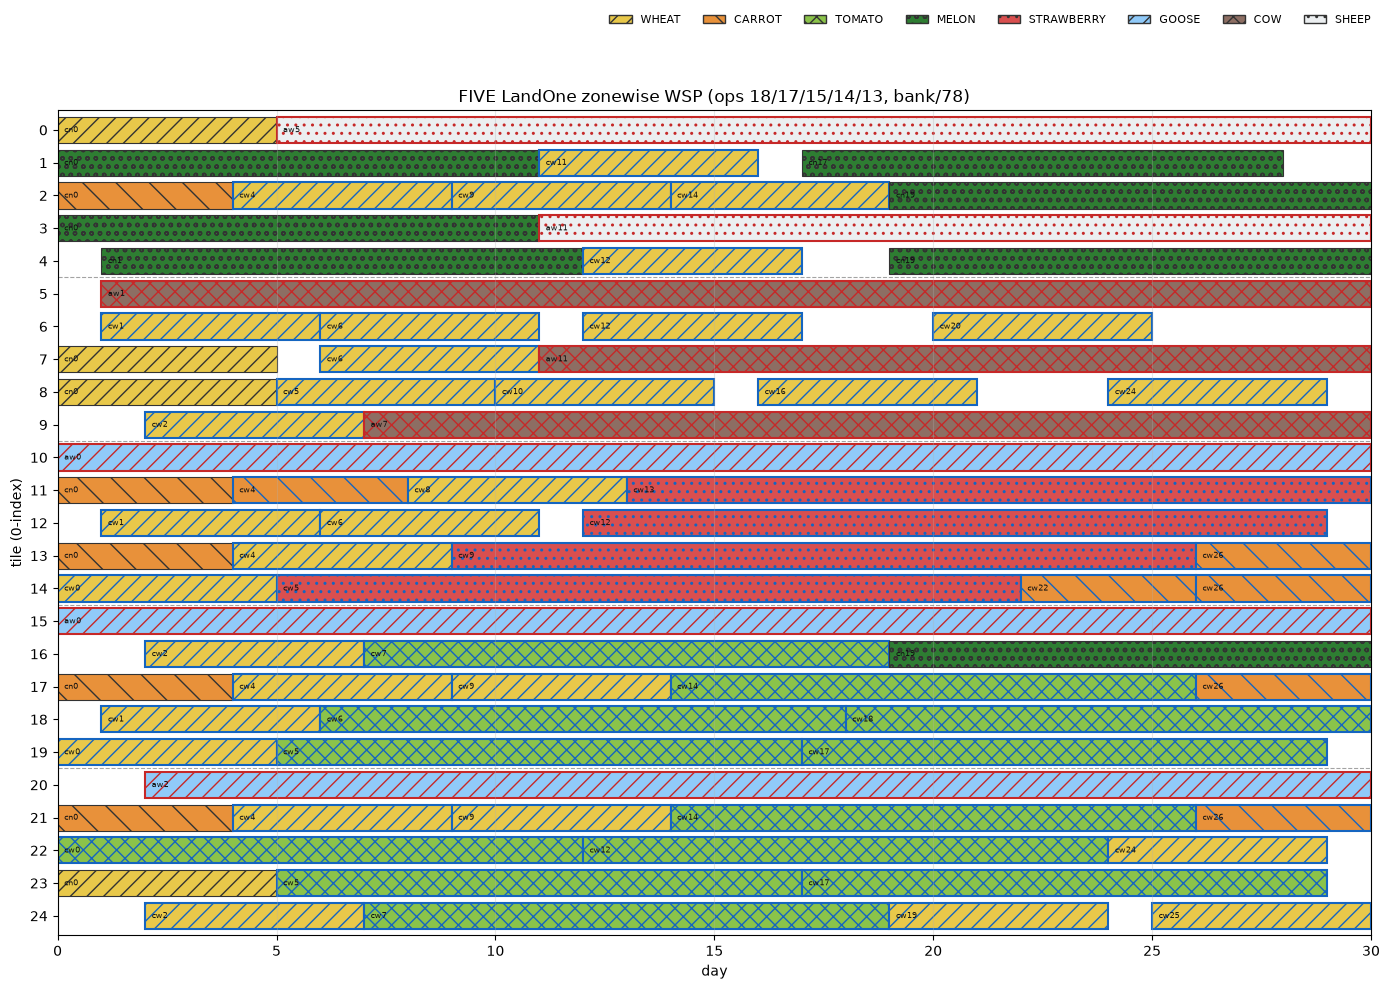

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

CROP_STYLE = {
    "WHEAT": {"color": "#e8c84a", "hatch": "//"},
    "CARROT": {"color": "#e8913a", "hatch": "\\"},
    "TOMATO": {"color": "#8bc34a", "hatch": "xx"},
    "MELON": {"color": "#2e7d32", "hatch": "oo"},
    "STRAWBERRY": {"color": "#d94f4f", "hatch": ".."},
}
ANIMAL_STYLE = {
    "GOOSE": {"color": "#90caf9", "hatch": "//"},
    "COW": {"color": "#8d6e63", "hatch": "xx"},
    "SHEEP": {"color": "#eceff1", "hatch": ".."},
}


def bar_style(segment):
    if segment["kind"] == "crop":
        st = dict(CROP_STYLE.get(segment["label"], {"color": "#999999", "hatch": ""}))
    else:
        st = dict(ANIMAL_STYLE.get(segment["label"], {"color": "#999999", "hatch": ""}))
    if segment["profile"] in ("with_fert", "with_care"):
        st["edgecolor"] = "#1565c0" if segment["kind"] == "crop" else "#c62828"
        st["linewidth"] = 1.5
    else:
        st.setdefault("edgecolor", "#333333")
        st.setdefault("linewidth", 0.8)
    return st


fig, ax = plt.subplots(figsize=(14, 10))
for row in selected:
    tile = row["tile"]
    seg = row["pattern"]["segment"]
    st = bar_style(seg)
    ax.barh(
        y=tile,
        width=seg["end_day"] - seg["start_day"],
        left=seg["start_day"],
        height=0.8,
        color=st["color"],
        hatch=st["hatch"],
        edgecolor=st["edgecolor"],
        linewidth=st["linewidth"],
    )
    tag = f"{seg['kind'][0]}{seg['profile'][0]}{seg['start_day']}"
    ax.text(seg["start_day"] + 0.15, tile, tag, va="center", fontsize=6, color="#111")

for yline in (4.5, 9.5, 14.5, 19.5):
    ax.axhline(yline, color="#666666", linewidth=0.8, linestyle="--", alpha=0.6)

ax.set_xlabel("day")
ax.set_ylabel("tile (0-index)")
ax.set_yticks(range(NUM_TILES))
ax.set_xlim(0, NUM_DAYS)
ax.set_ylim(-0.6, NUM_TILES - 0.4)
ax.set_title(
    "FIVE LandOne zonewise WSP "
    f"(ops {NET_TILE_OPS['farmer']}/"
    f"{NET_TILE_OPS['hire1']}/"
    f"{NET_TILE_OPS['hire2']}/"
    f"{NET_TILE_OPS['hire3']}/"
    f"{NET_TILE_OPS['hire4']}, bank/78)"
)
ax.invert_yaxis()
legend_handles = [
    Patch(facecolor=st["color"], hatch=st["hatch"], edgecolor="#333333", label=name)
    for name, st in {**CROP_STYLE, **ANIMAL_STYLE}.items()
]
ax.grid(axis="x", alpha=0.3)
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.99),
    bbox_transform=fig.transFigure,
    ncol=len(legend_handles),
    fontsize=8,
    frameon=False,
)
plt.show()



In [10]:
# Export SolveResult JSON (agent/solvers format); animal chains → first tiles per zone

import json
import sys
from collections import defaultdict
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from agent.solvers.common import decode_sort_key

OUT_PATH = ROOT / "agent" / "solvers" / "wsp_prestart.json"


def merge_tile_picks(picks):
    """Merge WSP patterns on one tile into a solver raw_chain (sorted by start_day)."""
    entries = [[p["pattern"]["profile_key"], p["pattern"]["start_day"]] for p in picks]
    entries.sort(key=lambda pair: pair[1])
    return entries


def zone_to_assigned(res):
    """Match decode_zone_assignment: sort chains, route animals to route-first tiles."""
    worker = res["worker"]
    zone_tiles = list(WORKER_TILES[worker])
    by_tile = defaultdict(list)
    for pick in res["selected"]:
        by_tile[pick["tile"]].append(pick)

    slots = [merge_tile_picks(by_tile[tile]) for tile in zone_tiles]
    slots.sort(key=decode_sort_key)
    return {tile: slots[i] for i, tile in enumerate(zone_tiles)}


assigned = {}
solved_workers = []
for res in zone_results:
    solved_workers.append(res["worker"])
    assigned.update(zone_to_assigned(res))

payload = {
    "assigned": {str(tile): chain for tile, chain in sorted(assigned.items())},
    "complete": len(zone_results) == len(WORKERS),
    "solved_workers": solved_workers,
}

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
with OUT_PATH.open("w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)
    f.write("\n")

print(f"wrote {OUT_PATH}")
print(f"  tiles={len(assigned)}  complete={payload['complete']}  workers={solved_workers}")
for worker in solved_workers:
    print(f"  {worker}:")
    for tile in WORKER_TILES[worker]:
        chain = assigned[tile]
        if not chain:
            print(f"    t{tile}: IDLE")
            continue
        body = ", ".join(f"{pk}@{sd}" for pk, sd in chain)
        print(f"    t{tile}: [{body}]")


wrote /media/wlaki/W/DS_projects/Kaggle/kaggriculture/agent/solvers/wsp_prestart.json
  tiles=25  complete=True  workers=['farmer', 'hire1', 'hire2', 'hire3', 'hire4']
  farmer:
    t0: [WHEAT_no_fert@0, SHEEP_with_care@5]
    t1: [MELON_no_fert@0, SHEEP_with_care@11]
    t2: [MELON_no_fert@0, WHEAT_with_fert@11, MELON_no_fert@17]
    t3: [CARROT_no_fert@0, WHEAT_with_fert@4, WHEAT_with_fert@9, WHEAT_with_fert@14, MELON_no_fert@19]
    t4: [MELON_no_fert@1, WHEAT_with_fert@12, MELON_no_fert@19]
  hire1:
    t5: [COW_with_care@1]
    t6: [WHEAT_with_fert@2, COW_with_care@7]
    t7: [WHEAT_no_fert@0, WHEAT_with_fert@6, COW_with_care@11]
    t8: [WHEAT_with_fert@1, WHEAT_with_fert@6, WHEAT_with_fert@12, WHEAT_with_fert@20]
    t9: [WHEAT_no_fert@0, WHEAT_with_fert@5, WHEAT_with_fert@10, WHEAT_with_fert@16, WHEAT_with_fert@24]
  hire2:
    t10: [GOOSE_with_care@0]
    t11: [CARROT_no_fert@0, CARROT_with_fert@4, WHEAT_with_fert@8, STRAWBERRY_with_fert@13]
    t12: [WHEAT_with_fert@1, WHEAT_